# **Micelles**

In [9]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
from scipy.special import gamma, jv, j1, j0
from scipy.special import erf
from scipy.integrate import simpson

# **Functions**

### Spheres

In [18]:
def sphere_amplitude(q, R):
    qR = q * R + 1e-10  # защита от деления на ноль
    return 4 * np.pi * R**3 * (np.sin(qR) - qR * np.cos(qR)) / (qR**3)

def sphere_form_factor(q, R, scale=1.0, bg=0.0):
    F = sphere_amplitude(q, R)
    return scale * np.abs(F)**2 + bg

def sphere_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale=1.0, bg=0.0):
    
    F_core = sphere_amplitude(q, R_core)
    F_shell = sphere_amplitude(q, R_shell)
    
    F = rho_core * F_core + rho_shell * (F_shell - F_core)
    
    return scale * np.abs(F)**2 + bg

In [69]:
from scipy.special import gamma, gammaln

def schulz_zimm_weights(R_vals, R_avg, polydispersity):
    """
    Веса распределения Шульца-Цимма (логарифмически стабильная версия).
    """
    z = 1 / polydispersity**2 - 1
    if z < 0:
        z = 0.1
    
    # Логарифмическая версия для стабильности
    log_weights = (z + 1) * np.log(z + 1) - (z + 1) * np.log(R_avg) - gammaln(z + 1) \
                  + z * np.log(R_vals) - (z + 1) * R_vals / R_avg
    
    weights = np.exp(log_weights)
    
    # Нормировка
    return weights / np.sum(weights)

def sphere_core_shell_polydisperse(q, R_core_avg, R_shell_avg, polydispersity,
                                   rho_core, rho_shell, scale=1.0, bg=0.0, n_pts=30):
    """
    Форм-фактор core-shell сферы с полидисперсностью по Шульцу-Цимму.
    
    Параметры:
    ----------
    q : array
        Переданный импульс (нм^-1)
    R_core_avg : float
        Средний радиус ядра (нм)
    R_shell_avg : float
        Средний полный радиус (нм)
    polydispersity : float
        Относительная полидисперсность (например, 0.1 = 10%)
    rho_core : float
        Контраст ядра
    rho_shell : float
        Контраст оболочки
    scale : float
        Масштаб
    bg : float
        Фон
    n_pts : int
        Число точек для интегрирования по распределению
    """
    # Диапазон интегрирования: от 0 до 3 сигм выше среднего
    sigma = polydispersity * R_shell_avg
    R_min = max(0.1, R_shell_avg - 3 * sigma)
    R_max = R_shell_avg + 3 * sigma
    
    R_vals = np.linspace(R_min, R_max, n_pts)
    weights = schulz_zimm_weights(R_vals, R_shell_avg, polydispersity)
    
    # Усреднение форм-фактора
    P_avg = np.zeros_like(q)
    for R, w in zip(R_vals, weights):
        # Масштабируем ядро пропорционально оболочке
        R_core_scaled = R_core_avg * (R / R_shell_avg)
        
        F_core = sphere_amplitude(q, R_core_scaled)
        F_shell = sphere_amplitude(q, R)
        
        F = rho_core * F_core + rho_shell * (F_shell - F_core)
        P_avg += w * np.abs(F)**2
    
    return scale * P_avg + bg

In [70]:
def forster_figure9a_form_factor(q):
    """
    Форм-фактор core-shell сферы с полидисперсностью.
    Параметры из статьи (рисунок 9a, PS-PI, BCC).
    """
    # Параметры из таблицы
    R_core_avg = 13.6      # нм
    R_shell_avg = 13.7     # нм (из объёмной доли φ = 0.111)
    polydispersity = 0.09  # 9%
    rho_core = 1.0
    rho_shell = 0.0        # почти нет оболочки (PI в PS)
    scale = 1.0
    bg = 0.0
    
    return sphere_core_shell_polydisperse(q, R_core_avg, R_shell_avg, 
                                          polydispersity, rho_core, rho_shell, 
                                          scale, bg)

[]

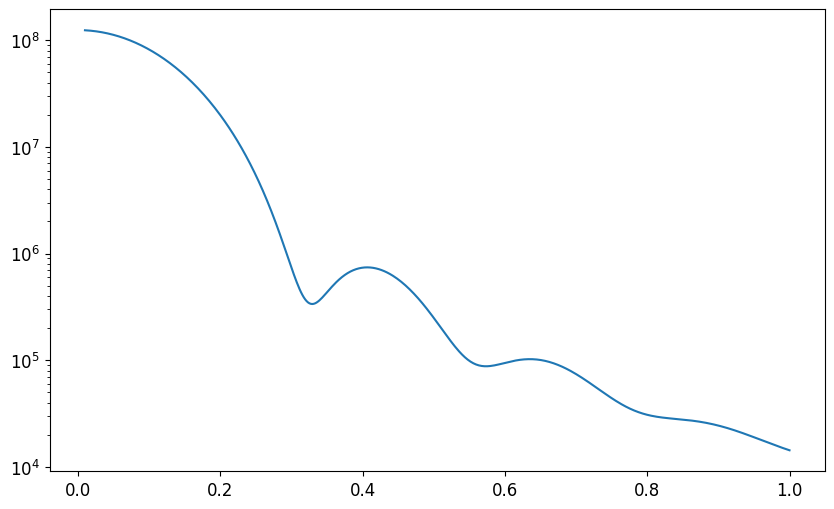

In [72]:
q = np.linspace(0.01, 1.0, 500)
P = forster_figure9a_form_factor(q)

plt.plot(q, P)

plt.semilogy()

### Cylinder

In [20]:
def cylinder_amplitude(q, R):
    qR = q * R + 1e-10
    return 2 * np.pi * R**2 * j1(qR) / qR

def cylinder_form_factor(q, R, scale=1.0, bg=0.0):
    F = cylinder_amplitude(q, R)
    P = np.abs(F)**2 / (q + 1e-10)
    return scale * P + bg

def cylinder_core_shell(q, R_core, R_shell, rho_core, rho_shell, scale=1.0, bg=0.0):

    F_core = cylinder_amplitude(q, R_core)
    F_shell = cylinder_amplitude(q, R_shell)
    
    F = rho_core * F_core + rho_shell * (F_shell - F_core)
    
    P = np.abs(F)**2 / (q + 1e-10)
    return scale * P + bg

### Ellipsoid

In [21]:
def ellipsoid_amplitude(q, Ra, Rb):
    nu = Rb / Ra
    theta = np.linspace(0, np.pi/2, 100)
    sin_t = np.sin(theta)
    cos_t = np.cos(theta)
    weights = sin_t / np.sum(sin_t)
    
    F_avg = np.zeros_like(q, dtype=complex)
    
    for i, qi in enumerate(q):
        Reff = Ra * np.sqrt(sin_t**2 + nu**2 * cos_t**2)
        x = qi * Reff + 1e-10
        F = 4 * np.pi * Ra**3 * nu * (np.sin(x) - x * np.cos(x)) / x**3
        F_avg[i] = np.sum(weights * F)
    
    return F_avg

def ellipsoid_form_factor(q, Ra, Rb, scale=1.0, bg=0.0):
    F = ellipsoid_amplitude(q, Ra, Rb)
    return scale * np.abs(F)**2 + bg

def ellipsoid_core_shell(q, R_core_a, R_core_b, R_shell_a, R_shell_b,
                         rho_core, rho_shell, scale=1.0, bg=0.0):
    
    # Амплитуда всего эллипсоида (как однородного)
    F_shell = ellipsoid_amplitude(q, R_shell_a, R_shell_b)
    
    # Амплитуда ядра (как однородного эллипсоида)
    F_core = ellipsoid_amplitude(q, R_core_a, R_core_b)
    
    # Core-shell амплитуда
    F = rho_core * F_core + rho_shell * (F_shell - F_core)
    
    return scale * np.abs(F)**2 + bg

### Lamella

In [13]:
def lamella_amplitude(q, t):
    qt = q * t + 1e-10
    return t * np.sin(qt / 2) / (qt / 2)

def lamella_form_factor(q, t, scale=1.0, bg=0.0):
    F = lamella_amplitude(q, t)
    return scale * np.abs(F)**2 + bg

### Math

In [17]:
def sqrt(a):
    return np.sqrt(a)

# **Data**

In [22]:
path = r'E:\Zalygin geles\5781\Zalygin_solutions_Liquid_100'
Exp100 = BM26_experiment(path)

# **Analysis**

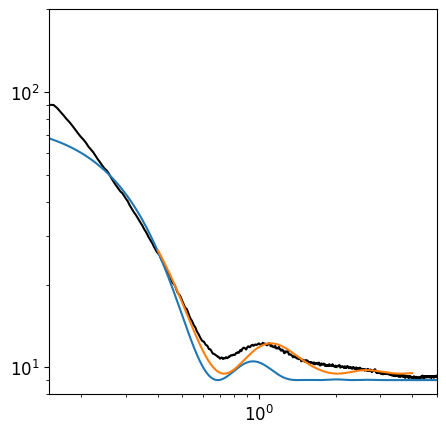

In [64]:
q, I = Exp100.get_1d_SAXS(10)

plt.figure(figsize=(5,5))
plt.loglog(q, I, color='black')

plt.xlim(0.15, 5)


R_core_a = 2
R_core_b = 2
R_shell_a = 6
R_shell_b = 6
rho_core = -1
rho_shell = 1


Pq = ellipsoid_core_shell(q, R_core_a, R_core_b, R_shell_a, R_shell_b, rho_core, rho_shell, scale=1e-4, bg=9.)

plt.plot(q, Pq)

plt.ylim(8, 2e2)

l, r = 0.4, 4
x = q[(q>l)*(q<r)]
y = I[(q>l)*(q<r)]

p, cov = curve_fit(ellipsoid_core_shell, x, y, p0=[ R_core_a, R_core_b, R_shell_a, R_shell_b, rho_core, rho_shell, 1e-4, 9.], 
                  bounds=((0,0,0,0,-np.inf, -np.inf, 0, 0), (np.inf,np.inf,np.inf,np.inf,np.inf,np.inf, np.inf, 9.5))
                  )

plt.plot(x, ellipsoid_core_shell(x, *p))

In [63]:
p

array([ 1.73540951e+00,  2.61211709e+00,  1.47672736e+00,  6.86840572e+00,
       -1.96134268e-01,  3.14350684e+00,  7.34177168e-03,  9.50000000e+00])